# LightGBM Baseline - Turkey STLF
**Target:** `actual_load` (MW) at horizon t+24h  
**Train:** 2018–2022 | **Val:** 2023 | **Test:** 2024–2025-03  
**Project:** Ramadan-Aware STLF Benchmarking

---
### Notebook Structure
1. Setup & Load  
2. Feature Engineering  
3. Train / Val / Test Split  
4. Baseline LightGBM (no Hijri features)  
5. Ramadan-Aware LightGBM (+ Hijri features)  
6. Optuna Hyperparameter Tuning  
7. Final Model Evaluation  
8. Regime-Conditional Error Analysis  
9. Feature Importance  

---
## Setup & Load

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
import optuna
from pathlib import Path
from scipy import stats

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

C_BLUE   = '#64b5f6'
C_ORANGE = '#ffb74d'
C_GREEN  = '#81c784'
C_RED    = '#e57373'
C_PURPLE = '#ba68c8'

REGIME_COLORS = {
    'Normal':   C_BLUE,
    'Ramadan':  C_ORANGE,
    'Heatwave': C_RED,
}

SEED = 42
print('Libraries loaded.')

Libraries loaded.


In [2]:
ROOT_DIR = Path().resolve().parents[0]
CSV_PATH = ROOT_DIR / 'data' / 'processed' / 'final_training_set_v1.csv'
MODEL_DIR = ROOT_DIR / 'models'
MODEL_DIR.mkdir(exist_ok=True, parents=True)

df = pd.read_csv(CSV_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df = df.set_index('timestamp').sort_index()

# Rebuild regime labels
daily_max  = df.groupby(df.index.date)['temp_c'].max()
HW_THRESH  = daily_max.quantile(0.95)
is_hot_day = daily_max >= HW_THRESH
hot_day_map = {d: int(v) for d, v in is_hot_day.items()}
df['is_heatwave'] = [hot_day_map.get(ts.date(), 0) for ts in df.index]

def regime(row):
    if row['is_ramadan']:  return 'Ramadan'
    elif row['is_heatwave']: return 'Heatwave'
    return 'Normal'

df['regime'] = df.apply(regime, axis=1)

print(f'Loaded: {len(df):,} rows | {df.index[0].date()} → {df.index[-1].date()}')
print(f'Regime counts:\n{df["regime"].value_counts().to_string()}')

Loaded: 70,125 rows | 2018-01-01 → 2025-12-31
Regime counts:
regime
Normal      60909
Ramadan      5688
Heatwave     3528


---
## Feature Engineering

All features are constructed so they are **available at forecast time** (t+24h horizon).  
Weather covariates use ERA5 reanalysis values at t+24 (treated as known forecasts).  
Lag features use only information up to time t.

In [3]:
# Cyclical encoding of calendar features
df['hour_sin']  = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos']  = np.cos(2 * np.pi * df.index.hour / 24)
df['dow_sin']   = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['dow_cos']   = np.cos(2 * np.pi * df.index.dayofweek / 7)
df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

# nonlinearity above ~31.75°C (P95 proxy), U-shaped load-temp curve
df['temp_sq']           = df['temp_c'] ** 2
df['temp_above_hw']     = (df['temp_c'] - HW_THRESH).clip(lower=0)  # heating above threshold
df['is_weekend']        = (df.index.dayofweek >= 5).astype(int)

# Ramadan × hour interaction iftar spike at UTC17, suhoor at UTC01
df['ramadan_x_hour_sin']   = df['is_ramadan'] * df['hour_sin']
df['ramadan_x_hour_cos']   = df['is_ramadan'] * df['hour_cos']
df['ramadan_x_weekend']    = df['is_ramadan'] * df['is_weekend']

# Heatwave × hour interaction peak AC load
df['heatwave_x_temp']      = df['is_heatwave'] * df['temp_c']

# Additional lag features
# lag-48h (two days ago, same hour) — useful for detecting trends
df['load_lag_48h']  = df['actual_load'].shift(48)
# lag-336h (two weeks ago, same hour)
df['load_lag_336h'] = df['actual_load'].shift(336)

# Rolling std over 168h, 24h window: in dataset

print('Feature engineering complete.')
print(f'Total columns: {len(df.columns)}')

Feature engineering complete.
Total columns: 34


---
## Train / Val / Test Split

In [4]:
# ── Feature sets ──────────────────────────────────────────────────────────
# Base features (NO Hijri) — used for ablation A
BASE_FEATURES = [
    # Weather
    'temp_c', 'dewpoint_c', 'wind_speed', 'solar_rad',
    'temp_sq', 'temp_above_hw',
    # Calendar (cyclical)
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    # Raw calendar (kept for tree splits)
    'hour', 'day_of_week', 'month',
    'is_weekend',
    # Lags
    'load_lag_24h', 'load_lag_48h', 'load_lag_168h', 'load_lag_336h',
    # Rolling stats
    'load_rolling_mean_24h', 'load_rolling_std_24h',
    'load_rolling_mean_168h', 'load_rolling_std_168h',
    # Heatwave
    'is_heatwave', 'heatwave_x_temp',
]

# Hijri features added for ablation B
HIJRI_FEATURES = [
    'is_ramadan', 'is_eid', 'day_of_ramadan',
    'ramadan_x_hour_sin', 'ramadan_x_hour_cos', 'ramadan_x_weekend',
]

ALL_FEATURES = BASE_FEATURES + HIJRI_FEATURES

TARGET = 'actual_load'

# ── Splits (no temporal leakage — strict chronological)
TRAIN = df.loc['2018':'2022'].dropna(subset=ALL_FEATURES + [TARGET])
VAL   = df.loc['2023'].dropna(subset=ALL_FEATURES + [TARGET])
TEST  = df.loc['2024':'2025-03'].dropna(subset=ALL_FEATURES + [TARGET])

X_train = TRAIN[ALL_FEATURES]
y_train = TRAIN[TARGET]

X_val   = VAL[ALL_FEATURES]
y_val   = VAL[TARGET]

X_test  = TEST[ALL_FEATURES]
y_test  = TEST[TARGET]

print(f'Train : {len(X_train):,} rows ({TRAIN.index[0].date()} → {TRAIN.index[-1].date()})')
print(f'Val   : {len(X_val):,} rows ({VAL.index[0].date()} → {VAL.index[-1].date()})')
print(f'Test  : {len(X_test):,} rows ({TEST.index[0].date()} → {TEST.index[-1].date()})')
print(f'\nBase features : {len(BASE_FEATURES)}')
print(f'Hijri features: {len(HIJRI_FEATURES)}')
print(f'Total features: {len(ALL_FEATURES)}')

Train : 43,488 rows (2018-01-15 → 2022-12-31)
Val   : 8,760 rows (2023-01-01 → 2023-12-31)
Test  : 10,944 rows (2024-01-01 → 2025-03-31)

Base features : 26
Hijri features: 6
Total features: 32


---
## Metric Helpers

In [5]:
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error — exclude zeros to avoid division issues."""
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def mase(y_true, y_pred, y_train, period=168):
    """
    Mean Absolute Scaled Error vs seasonal naive (lag-168).
    """
    y_train = np.asarray(y_train)
    # seasonal naive errors
    naive = np.abs(y_train[period:] - y_train[:-period])
    scale = np.mean(naive)
    return mean_absolute_error(y_true, y_pred) / scale

def evaluate(y_true, y_pred, y_train, label=''):
    """Print and return full metric dict."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mp   = mape(y_true, y_pred)
    ms   = mase(y_true, y_pred, y_train)
    if label:
        print(f'  [{label}]')
    print(f'  MAE  : {mae:>9.2f} MW')
    print(f'  RMSE : {rmse:>9.2f} MW')
    print(f'  MAPE : {mp:>9.4f} %')
    print(f'  MASE : {ms:>9.4f}')
    return {'label': label, 'MAE': mae, 'RMSE': rmse, 'MAPE': mp, 'MASE': ms}

def regime_evaluate(y_true, y_pred, regimes, y_train):
    """Evaluate per regime — mirrors proposal Table 3 stratification."""
    rows = []
    for r in ['Normal', 'Ramadan', 'Heatwave']:
        mask = regimes == r
        if mask.sum() == 0:
            rows.append({'Regime': r, 'N': 0, 'MAE': np.nan, 'RMSE': np.nan,
                         'MAPE': np.nan, 'MASE': np.nan})
            continue
        yt = y_true[mask]
        yp = y_pred[mask]
        rows.append({
            'Regime': r,
            'N': int(mask.sum()),
            'MAE':  round(mean_absolute_error(yt, yp), 2),
            'RMSE': round(np.sqrt(mean_squared_error(yt, yp)), 2),
            'MAPE': round(mape(yt, yp), 4),
            'MASE': round(mase(yt, yp, y_train), 4),
        })
    return pd.DataFrame(rows).set_index('Regime')

---
## Baseline LightGBM (No Hijri Features)
Ablation A control, identical hyperparameters, only feature set differs.

In [6]:
# Default params
DEFAULT_PARAMS = {
    'objective':        'regression',
    'metric':           'mae',
    'boosting_type':    'gbdt',
    'n_estimators':     2000,
    'learning_rate':    0.05,
    'num_leaves':       63,
    'max_depth':        8,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     1,
    'lambda_l1':        0.1,
    'lambda_l2':        5.0,
    'verbose':          -1,
    'random_state':     SEED,
    'n_jobs':           -1,
}

# ── Train baseline (no Hijri) ─────────────────────────────────────────────
model_base = lgb.LGBMRegressor(**DEFAULT_PARAMS)
model_base.fit(
    X_train[BASE_FEATURES], y_train,
    eval_set=[(X_val[BASE_FEATURES], y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False)
    ]
)

pred_base_val  = model_base.predict(X_val[BASE_FEATURES])
pred_base_test = model_base.predict(X_test[BASE_FEATURES])

print('\n=== Baseline (no Hijri) — Validation ===')
metrics_base_val  = evaluate(y_val.values,  pred_base_val,  y_train, 'Val')
print('\n=== Baseline (no Hijri) — Test ===')
metrics_base_test = evaluate(y_test.values, pred_base_test, y_train, 'Test')


=== Baseline (no Hijri) — Validation ===
  [Val]
  MAE  :    568.18 MW
  RMSE :    858.17 MW
  MAPE :    1.5587 %
  MASE :    0.3425

=== Baseline (no Hijri) — Test ===
  [Test]
  MAE  :    812.56 MW
  RMSE :   1219.30 MW
  MAPE :    2.0547 %
  MASE :    0.4898


---
## Ramadan-Aware LightGBM (+ Hijri Features)
Same default params — only difference is Hijri features added.

In [7]:
model_hijri = lgb.LGBMRegressor(**DEFAULT_PARAMS)
model_hijri.fit(
    X_train[ALL_FEATURES], y_train,
    eval_set=[(X_val[ALL_FEATURES], y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
    ]
)

pred_hijri_val  = model_hijri.predict(X_val[ALL_FEATURES])
pred_hijri_test = model_hijri.predict(X_test[ALL_FEATURES])

print('\n=== Hijri-Aware — Validation ===')
metrics_hijri_val  = evaluate(y_val.values,  pred_hijri_val,  y_train, 'Val')
print('\n=== Hijri-Aware — Test ===')
metrics_hijri_test = evaluate(y_test.values, pred_hijri_test, y_train, 'Test')


=== Hijri-Aware — Validation ===
  [Val]
  MAE  :    563.27 MW
  RMSE :    854.96 MW
  MAPE :    1.5449 %
  MASE :    0.3395

=== Hijri-Aware — Test ===
  [Test]
  MAE  :    791.90 MW
  RMSE :   1171.01 MW
  MAPE :    1.9936 %
  MASE :    0.4774


---
## Optuna Hyperparameter Tuning
50-trial TPE search on validation MAE — matches proposal Section 4.2.

In [8]:
def objective(trial):
    params = {
        'objective':         'regression',
        'metric':            'mae',
        'boosting_type':     'gbdt',
        'verbose':           -1,
        'random_state':      SEED,
        'n_jobs':            -1,
        'n_estimators':      2000,
        'learning_rate':     trial.suggest_float('learning_rate',  0.01,  0.1,  log=True),
        'num_leaves':        trial.suggest_int('num_leaves',       31,    255),
        'max_depth':         trial.suggest_int('max_depth',        4,     12),
        'min_child_samples': trial.suggest_int('min_child_samples',10,    100),
        'feature_fraction':  trial.suggest_float('feature_fraction',0.5,  1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction',0.5,  1.0),
        'bagging_freq':      1,
        'lambda_l1':         trial.suggest_float('lambda_l1',      1e-4,  10.0, log=True),
        'lambda_l2':         trial.suggest_float('lambda_l2',      1e-4,  10.0, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0,   1.0),
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train[ALL_FEATURES], y_train,
        eval_set=[(X_val[ALL_FEATURES], y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1),
        ]
    )
    pred = model.predict(X_val[ALL_FEATURES])
    return mean_absolute_error(y_val, pred)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest Val MAE : {study.best_value:.2f} MW')
print(f'Best params  :')
for k, v in study.best_params.items():
    print(f'  {k:<25}: {v}')

Best trial: 31. Best value: 542.035: 100%|█████| 50/50 [09:18<00:00, 11.17s/it]


Best Val MAE : 542.04 MW
Best params  :
  learning_rate            : 0.014879647089917045
  num_leaves               : 207
  max_depth                : 8
  min_child_samples        : 88
  feature_fraction         : 0.542001638189677
  bagging_fraction         : 0.7524974081412371
  lambda_l1                : 0.00020237768758336368
  lambda_l2                : 1.822809479683475
  min_split_gain           : 0.09634383125386695


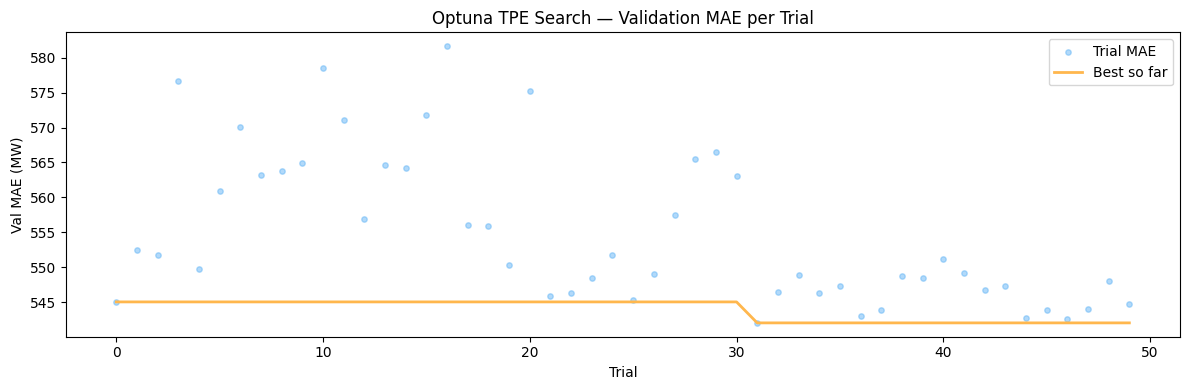

In [9]:
# ── Optuna convergence plot ───────────────────────────────────────────────
trial_vals = [t.value for t in study.trials]
best_so_far = pd.Series(trial_vals).cummin()

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(range(len(trial_vals)), trial_vals, s=15, alpha=0.5, color=C_BLUE, label='Trial MAE')
ax.plot(best_so_far.values, color=C_ORANGE, lw=2, label='Best so far')
ax.set_title('Optuna TPE Search — Validation MAE per Trial')
ax.set_xlabel('Trial')
ax.set_ylabel('Val MAE (MW)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Final Tuned Model

In [10]:
BEST_PARAMS = {
    'objective':     'regression',
    'metric':        'mae',
    'boosting_type': 'gbdt',
    'verbose':       -1,
    'random_state':  SEED,
    'n_jobs':        -1,
    'n_estimators':  3000,   # more trees with best LR
    **study.best_params,
}

model_tuned = lgb.LGBMRegressor(**BEST_PARAMS)
model_tuned.fit(
    X_train[ALL_FEATURES], y_train,
    eval_set=[(X_val[ALL_FEATURES], y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False)
    ]
)

pred_tuned_val  = model_tuned.predict(X_val[ALL_FEATURES])
pred_tuned_test = model_tuned.predict(X_test[ALL_FEATURES])

print('\n=== TUNED Hijri-Aware — Validation ===')
metrics_tuned_val  = evaluate(y_val.values,  pred_tuned_val,  y_train, 'Val')
print('\n=== TUNED Hijri-Aware — Test ===')
metrics_tuned_test = evaluate(y_test.values, pred_tuned_test, y_train, 'Test')


=== TUNED Hijri-Aware — Validation ===
  [Val]
  MAE  :    542.63 MW
  RMSE :    806.20 MW
  MAPE :    1.4881 %
  MASE :    0.3271

=== TUNED Hijri-Aware — Test ===
  [Test]
  MAE  :    790.24 MW
  RMSE :   1165.98 MW
  MAPE :    1.9803 %
  MASE :    0.4764


---
## Full Evaluation & Visualisation

In [11]:
# ── Model comparison table ────────────────────────────────────────────────
comparison = pd.DataFrame([
    {**metrics_base_test,  'model': 'LightGBM — No Hijri (default)'},
    {**metrics_hijri_test, 'model': 'LightGBM — Hijri (default)'},
    {**metrics_tuned_test, 'model': 'LightGBM — Hijri (Optuna tuned)'},
]).set_index('model')[['MAE','RMSE','MAPE','MASE']]

print('=== Test Set Model Comparison ===')
print(comparison.round(3).to_string())

=== Test Set Model Comparison ===
                                     MAE      RMSE   MAPE   MASE
model                                                           
LightGBM — No Hijri (default)    812.563  1219.295  2.055  0.490
LightGBM — Hijri (default)       791.901  1171.008  1.994  0.477
LightGBM — Hijri (Optuna tuned)  790.241  1165.975  1.980  0.476


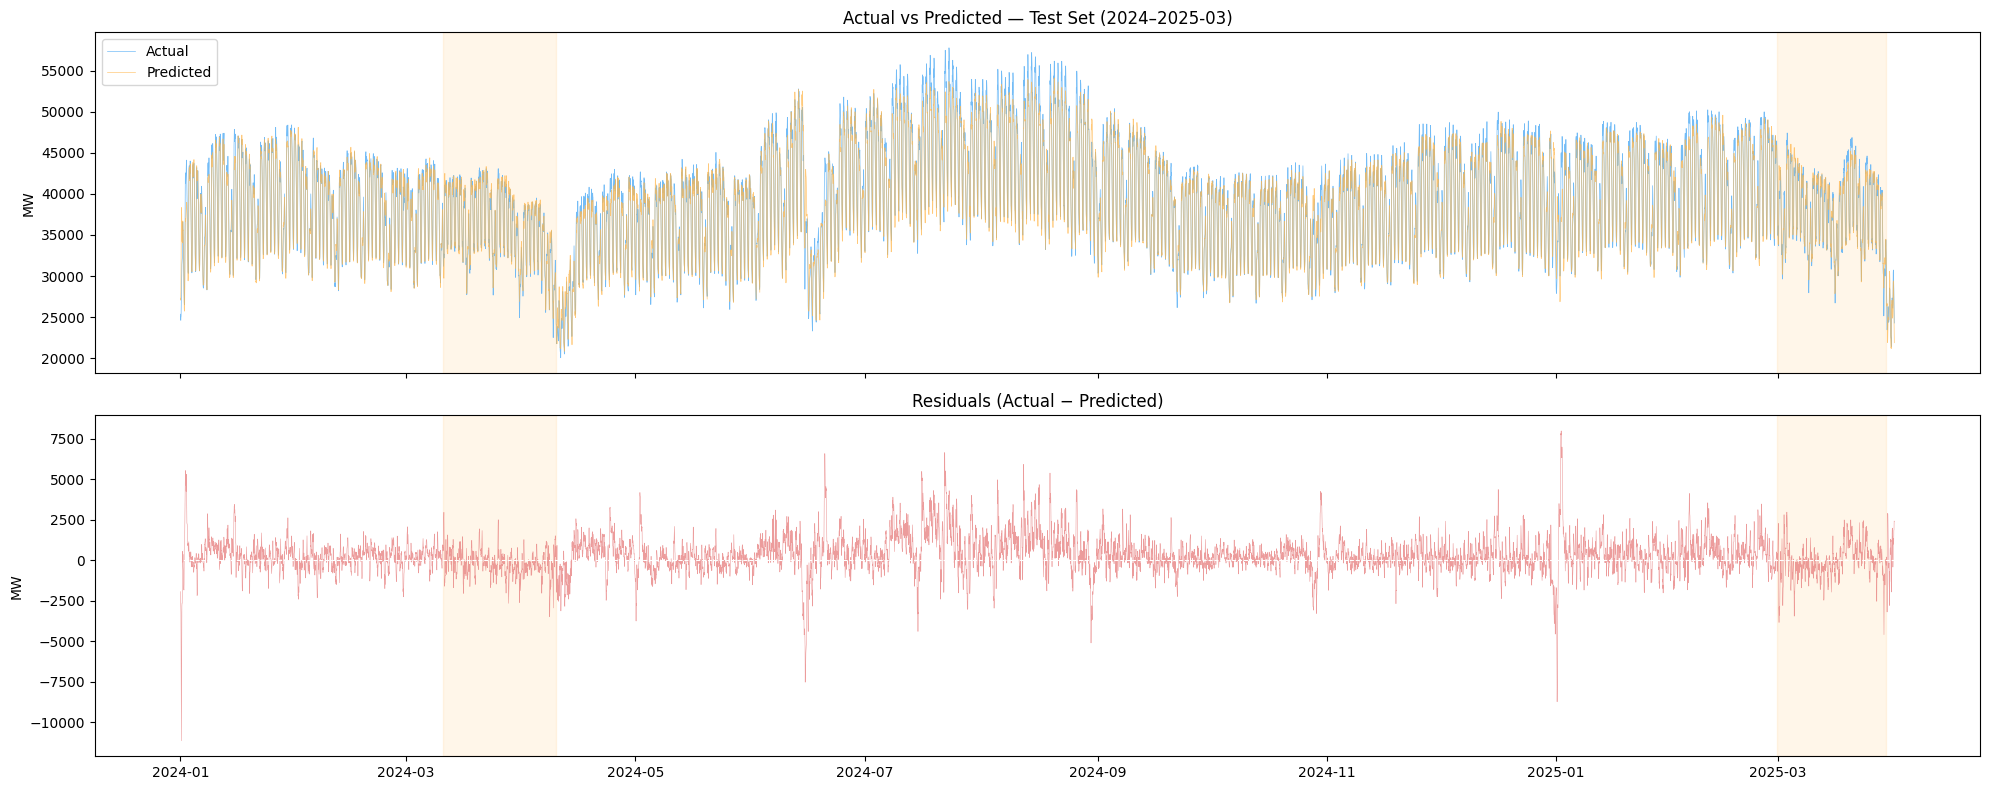

In [12]:
# ── Actual vs Predicted — full test set ──────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(20, 8), sharex=True)

axes[0].plot(TEST.index, y_test.values,      color=C_BLUE,   lw=0.5, alpha=0.9,  label='Actual')
axes[0].plot(TEST.index, pred_tuned_test,    color=C_ORANGE, lw=0.5, alpha=0.75, label='Predicted')
axes[0].set_title('Actual vs Predicted — Test Set (2024–2025-03)')
axes[0].set_ylabel('MW')
axes[0].legend()

residuals = y_test.values - pred_tuned_test
axes[1].plot(TEST.index, residuals, color=C_RED, lw=0.4, alpha=0.7)
axes[1].axhline(0, color='white', lw=0.8, ls='--')
axes[1].set_title('Residuals (Actual − Predicted)')
axes[1].set_ylabel('MW')

# Shade Ramadan windows on test set
in_ram = False; r_start = None
for ts, val in TEST['is_ramadan'].items():
    if val == 1 and not in_ram:  r_start = ts; in_ram = True
    elif val == 0 and in_ram:
        for ax in axes:
            ax.axvspan(r_start, ts, alpha=0.12, color=C_ORANGE)
        in_ram = False

plt.tight_layout()
plt.show()

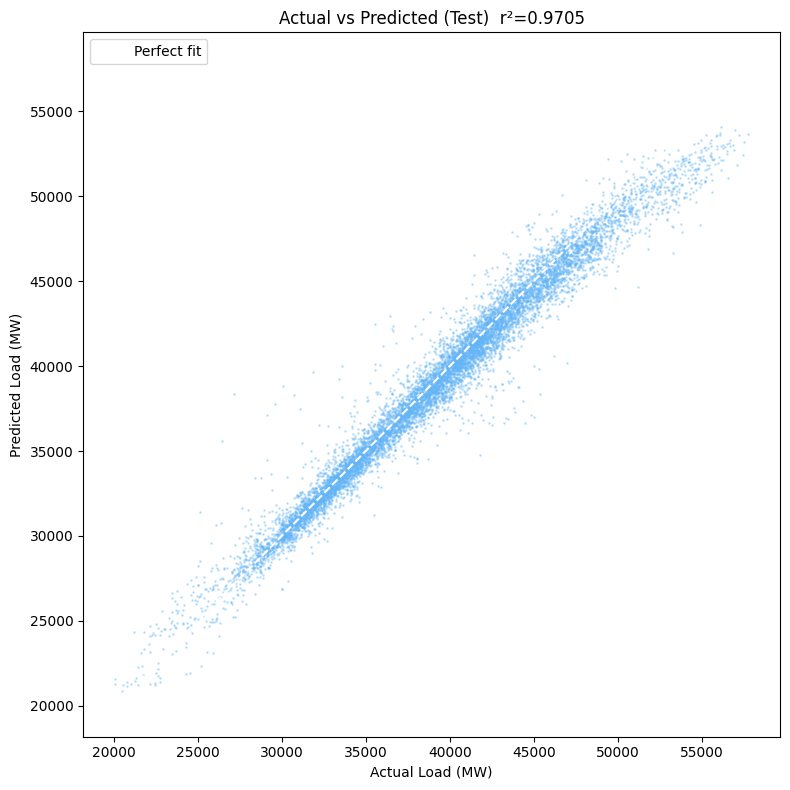

In [13]:
# ── Scatter: Actual vs Predicted ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test.values, pred_tuned_test, s=1, alpha=0.3, color=C_BLUE, rasterized=True)
lims = [min(y_test.min(), pred_tuned_test.min()),
        max(y_test.max(), pred_tuned_test.max())]
ax.plot(lims, lims, color='white', lw=1.5, ls='--', label='Perfect fit')
r, _ = stats.pearsonr(y_test.values, pred_tuned_test)
ax.set_title(f'Actual vs Predicted (Test)  r²={r**2:.4f}')
ax.set_xlabel('Actual Load (MW)')
ax.set_ylabel('Predicted Load (MW)')
ax.legend()
plt.tight_layout()
plt.show()

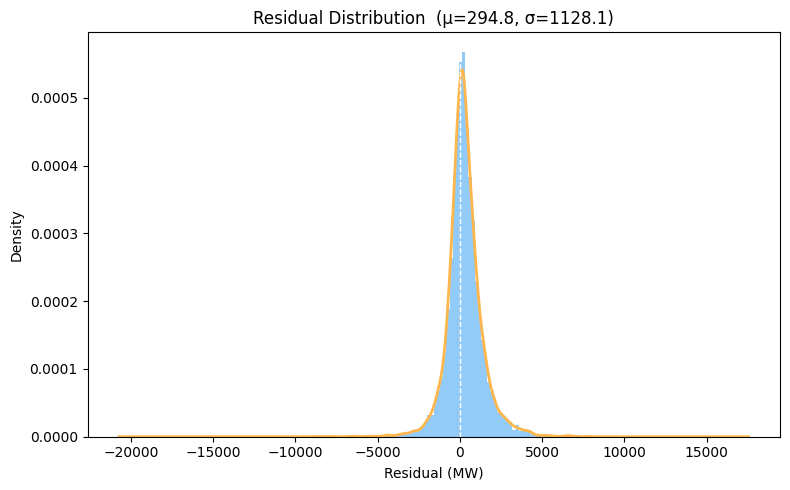

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.hist(residuals, bins=100, color=C_BLUE, alpha=0.7, density=True)
pd.Series(residuals).plot.kde(ax=ax, color=C_ORANGE, lw=2)

ax.axvline(0, color='white', lw=1, ls='--')
ax.set_title(f'Residual Distribution  (μ={residuals.mean():.1f}, σ={residuals.std():.1f})')
ax.set_xlabel('Residual (MW)')
ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

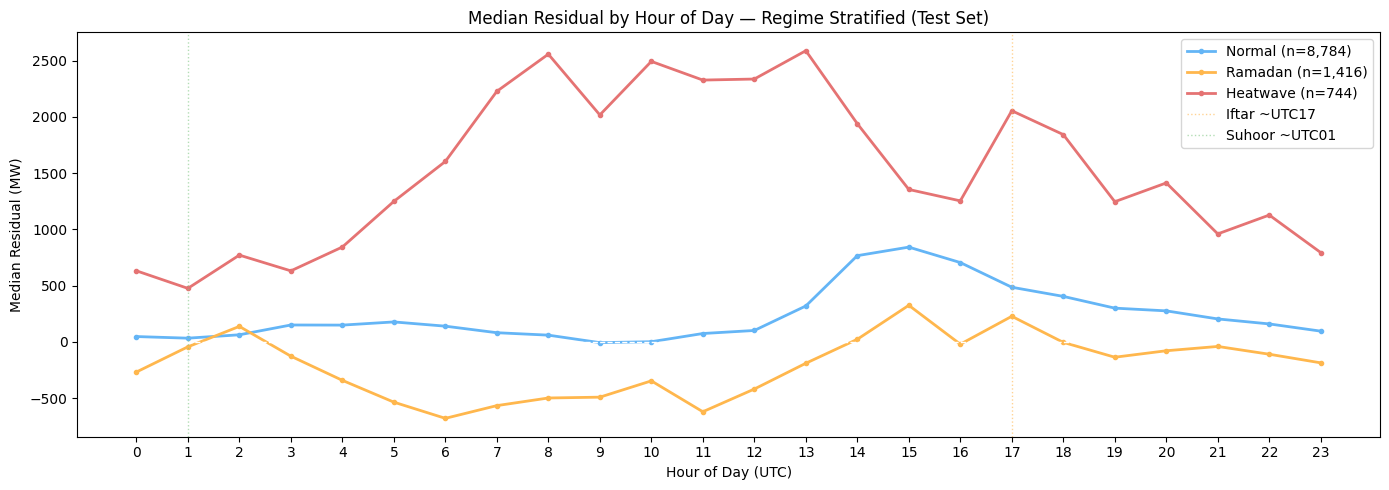

In [15]:
# ── Residual by hour of day ───────────────────────────────────────────────
res_df = pd.DataFrame({
    'residual': residuals,
    'hour':     TEST.index.hour,
    'regime':   TEST['regime'].values,
})

fig, ax = plt.subplots(figsize=(14, 5))
for regime_name, color in REGIME_COLORS.items():
    sub = res_df[res_df['regime'] == regime_name]
    if len(sub) == 0: continue
    grp = sub.groupby('hour')['residual'].median()
    ax.plot(range(24), grp.reindex(range(24)).values,
            color=color, lw=2, label=f'{regime_name} (n={len(sub):,})', marker='o', markersize=3)

ax.axhline(0, color='white', lw=1, ls='--')
ax.axvline(17, color=C_ORANGE, ls=':', lw=1, alpha=0.6, label='Iftar ~UTC17')
ax.axvline(1,  color=C_GREEN,  ls=':', lw=1, alpha=0.6, label='Suhoor ~UTC01')
ax.set_title('Median Residual by Hour of Day — Regime Stratified (Test Set)')
ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Median Residual (MW)')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()

## Regime-Conditional Error Analysis  

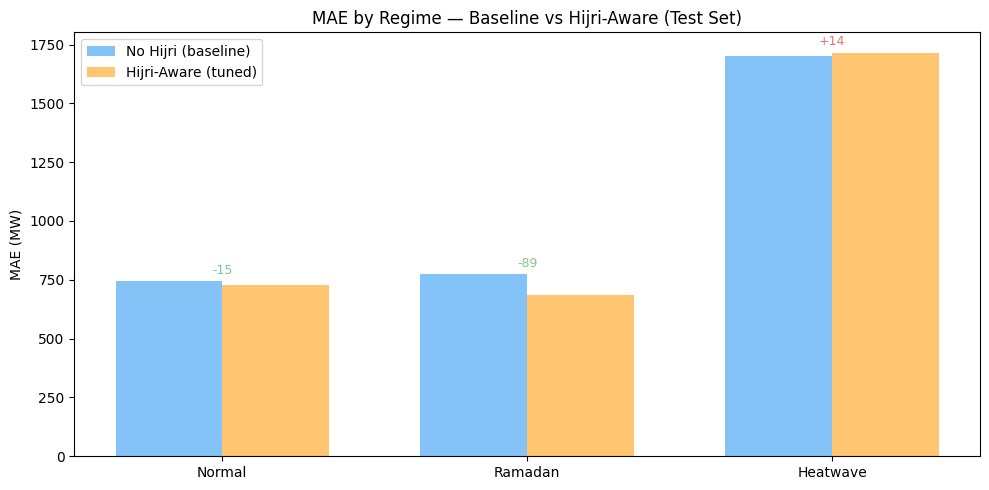

In [17]:
# ── Regime error bar chart ────────────────────────────────────────────────
regimes_plot = ['Normal', 'Ramadan', 'Heatwave']
x = np.arange(len(regimes_plot))
w = 0.35

mae_base  = [regime_metrics_base.loc[r, 'MAE']  if r in regime_metrics_base.index else np.nan for r in regimes_plot]
mae_tuned = [regime_metrics_tuned.loc[r, 'MAE'] if r in regime_metrics_tuned.index else np.nan for r in regimes_plot]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, mae_base,  width=w, color=C_BLUE,   alpha=0.8, label='No Hijri (baseline)')
ax.bar(x + w/2, mae_tuned, width=w, color=C_ORANGE, alpha=0.8, label='Hijri-Aware (tuned)')

for i, (b, t) in enumerate(zip(mae_base, mae_tuned)):
    if not np.isnan(b) and not np.isnan(t):
        delta_val = t - b
        ax.text(i, max(b, t) + 30, f'{delta_val:+.0f}', ha='center', fontsize=9,
                color=C_GREEN if delta_val < 0 else C_RED)

ax.set_xticks(x)
ax.set_xticklabels(regimes_plot)
ax.set_title('MAE by Regime — Baseline vs Hijri-Aware (Test Set)')
ax.set_ylabel('MAE (MW)')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# ── Per-year Ramadan error: Baseline vs Hijri-Aware ───────────────────────
print('=== Ramadan MAE per year — Baseline vs Hijri-Aware (TEST: 2024–2025) ===')

res_full = pd.DataFrame({
    'actual':    y_test.values,
    'pred_base': pred_base_test,
    'pred_hijri':pred_tuned_test,
    'regime':    TEST['regime'].values,
    'year':      TEST.index.year,
}, index=TEST.index)

for year in sorted(res_full['year'].unique()):
    sub = res_full[(res_full['year'] == year) & (res_full['regime'] == 'Ramadan')]
    if len(sub) == 0:
        print(f'  {year}: no Ramadan hours in test set')
        continue
    mae_b = mean_absolute_error(sub['actual'], sub['pred_base'])
    mae_h = mean_absolute_error(sub['actual'], sub['pred_hijri'])
    print(f'  {year} (n={len(sub):,}): Base={mae_b:.1f} MW | Hijri={mae_h:.1f} MW | Δ={mae_h-mae_b:+.1f} MW')

=== Ramadan MAE per year — Baseline vs Hijri-Aware (TEST: 2024–2025) ===
  2024 (n=720): Base=719.2 MW | Hijri=591.5 MW | Δ=-127.6 MW
  2025 (n=696): Base=828.4 MW | Hijri=779.5 MW | Δ=-48.9 MW


---
## Feature Importance

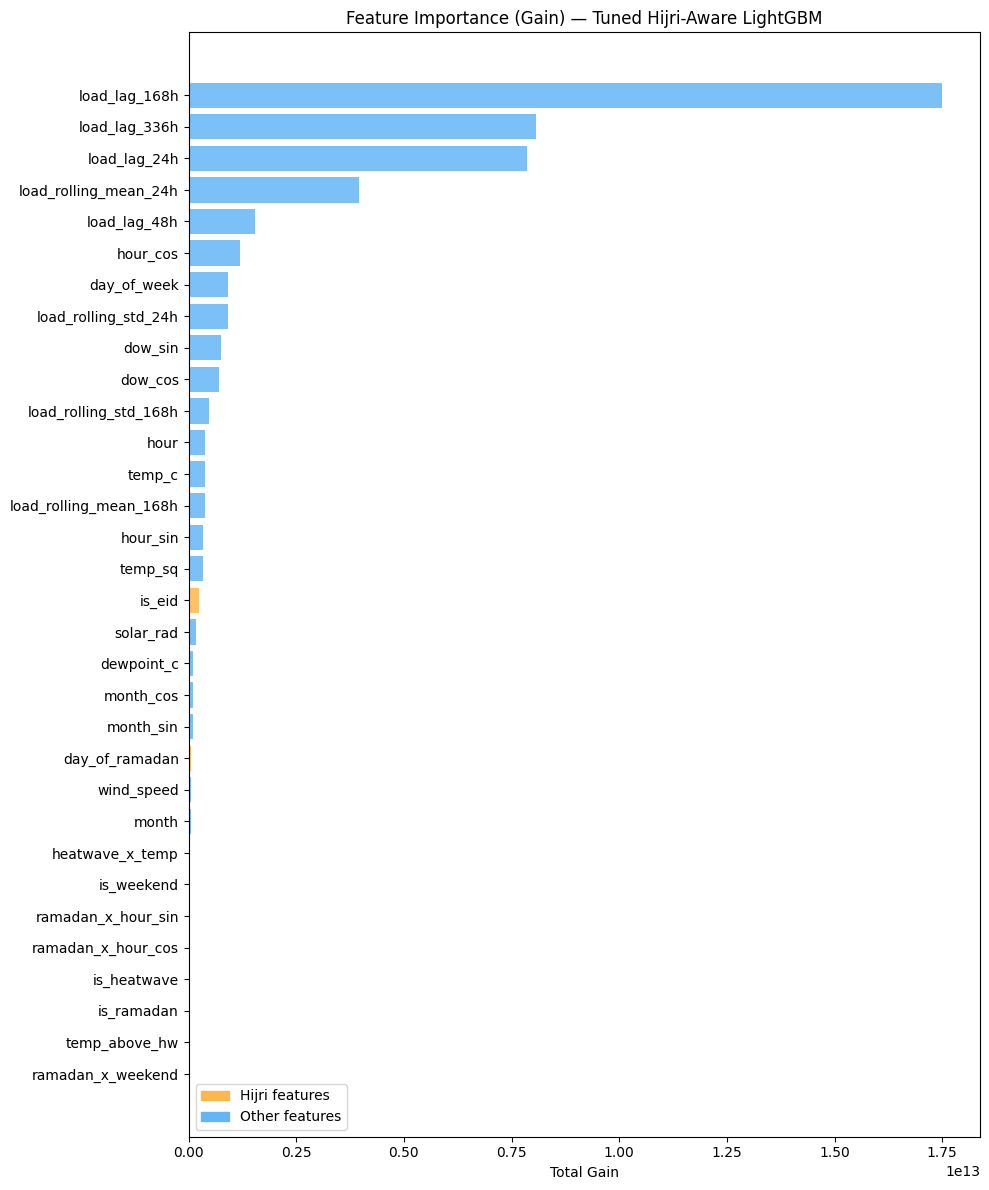


=== Top 10 features by gain ===
load_lag_168h            1.750348e+13
load_lag_336h            8.056123e+12
load_lag_24h             7.859539e+12
load_rolling_mean_24h    3.946002e+12
load_lag_48h             1.536144e+12
hour_cos                 1.190927e+12
day_of_week              9.099820e+11
load_rolling_std_24h     9.051744e+11
dow_sin                  7.510532e+11
dow_cos                  7.135412e+11


In [19]:
# ── LightGBM gain importance ──────────────────────────────────────────────
imp = pd.Series(
    model_tuned.booster_.feature_importance(importance_type='gain'),
    index=ALL_FEATURES
).sort_values(ascending=True)

# Colour Hijri features distinctly
colors_imp = [C_ORANGE if f in HIJRI_FEATURES else C_BLUE for f in imp.index]

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(imp.index, imp.values, color=colors_imp, alpha=0.85)
ax.set_title('Feature Importance (Gain) — Tuned Hijri-Aware LightGBM')
ax.set_xlabel('Total Gain')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=C_ORANGE, label='Hijri features'),
    Patch(color=C_BLUE,   label='Other features'),
])
plt.tight_layout()
plt.show()

print('\n=== Top 10 features by gain ===')
print(imp.sort_values(ascending=False).head(10).round(0).to_string())